In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pyfits
import h5py
from tqdm import tqdm

from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.PointSource.point_source import PointSource
import lenstronomy.Util.simulation_util as sim_util
from lenstronomy.Util import kernel_util
import lenstronomy.Util.util as util

In [2]:
data_image_set = np.load("sim_image_noisy_set.npy")

pb_sim = pyfits.getdata("..//fits//sim_noise1.pb.fits")
pb_sim = pb_sim[0][0]
pb_sim = np.nan_to_num(pb_sim)

psf_sim = pyfits.getdata("..//fits//sim_noise1.psf.fits")
psf_sim = psf_sim[0][0]
psf_sim=np.nan_to_num(psf_sim)

In [3]:
pb_cut = pb_sim[50:150, 50:150] * 0.9  # use a pb of values smaller than 1 to test the pb implementation
psf_pixel = psf_sim[150:351,150:351]

In [4]:
background_rms = 1e-4
exp_time = np.inf  #  exposure time (arbitrary units, flux per pixel is in units #photons/exp_time unit)
numPix = 100  #  cutout pixel size
deltaPix = 0.035  #  pixel size in arcsec (area per pixel = deltaPix**2)
psf_type = 'PIXEL'  # 'gaussian', 'pixel', 'NONE'
kernel_size = 201  # PSF kernel size (odd number required).

# generate the coordinate grid and image properties
kwargs_data = sim_util.data_configure_simple(numPix, deltaPix, exp_time, background_rms)
kwargs_data['ra_at_xy_0'] = -(50)*deltaPix
kwargs_data['dec_at_xy_0'] = -(50)*deltaPix
kwargs_data['antenna_primary_beam'] = pb_cut
kwargs_data['likelihood_method'] = 'interferometry_natwt'

# generate the psf variables
kernel_cut = kernel_util.cut_psf(psf_pixel, kernel_size, normalisation=False)
kwargs_psf = {'psf_type': psf_type, 'pixel_size': deltaPix,
                    'kernel_point_source': kernel_cut, 'kernel_point_source_normalisation': False}
psf_class = PSF(**kwargs_psf)
data_class = ImageData(**kwargs_data)

kwargs_numerics = {'supersampling_convolution': False}

C:\Users\ZN\AppData\Roaming\Python\Python311\site-packages\lenstronomy\Data\psf.py:95: UserWarning: Input PSF model has at least one negative element, which is unphysical except for a PSF of an interferometric array.
  warnings.warn(


In [8]:
correct_param_ra_dec_image = [-0.28, -1.33, 0.87, -0.64, -0.15, 0.41, -0.41, 1.3, 0.13, -0.55]
correct_param_point_amp = [47e-4, 39e-4, 43e-4, 56e-4, 49e-4]

quantiles of the image positions of the unlensed point sources

In [6]:
# the index means [sim number, sample, ra_image and dec_image params], there are 10 simulations and 10 params, might be confusing
chain_list = np.zeros((10, 30000, 10))

for sim in range(10):
    with h5py.File('fitting results//chain_fitting_unlensed_ps_sim' + str(sim) + '.h5', 'r') as f:
        chain_mcmc = f['chain'][:]
    chain_list[sim] = chain_mcmc

In [7]:
def correct_prediction_for_100intervals(chain_single_param, param_correct):
    quantile_x = np.linspace(0,1,101)
    prediction = np.zeros((101))

    for i in range(101):
        half_bar = 0.5 * quantile_x[i]
        param_interval_temp = np.zeros((2))
        param_interval_temp = np.quantile(chain_single_param, (0.5 - half_bar, 0.5 + half_bar))
        count_on_errorbar_temp = 0
        if (param_correct > param_interval_temp[0]) and (param_correct < param_interval_temp[1]):
            count_on_errorbar_temp = 1
        prediction[i] = count_on_errorbar_temp
    return prediction

In [10]:
quantile_ra_dec_image_unlensed_ps = np.zeros((101))
n_count = 0
for i in tqdm(range(10)):
    for j in range(10):
    
        quantile_ra_dec_image_unlensed_ps += correct_prediction_for_100intervals(
            chain_list[i,:,j], correct_param_ra_dec_image[j])
        n_count += 1
    
quantile_ra_dec_image_unlensed_ps /= n_count

100%|██████████| 10/10 [00:06<00:00,  1.45it/s]


Now we use the chain of the independent linear parameters and solved nonlinear parameters to solve for the amps of the point source
- Note that the 1sigma error bars of amplitudes are **not** estimated by linear solving the amplitude of each sample and taking the quantile.
- Instead, we treat each sample point as an independent gaussian likelihood function of the amplitudes, and compute the average and uncertainty using
$$\mu = \frac{1}{N_{sample}}\sum \mu_i$$
$$\sigma^2 = \frac{1}{N_{sample}}\sum(\sigma^2_i+\mu_i^2) - \mu^2$$
where $i$ stands for the sample index.
- $\mu_i$ is the average amplitude for each sample, and is the `params_coefficient` output of the linear solver.
- $\sigma_i^2$ is the variance of the amplitude for each sample, and is the diagonal entries of the `param_cov` output of the linear solver.

In [21]:
from scipy.stats import norm
def sigma_from_percentile(p):
    return norm.ppf((1 + p) / 2)

In [11]:
from lenstronomy.ImSim.image_linear_solve import ImageLinearFit
point_source_model_list = ['UNLENSED']
point_source_class = PointSource(point_source_type_list=point_source_model_list)

In [33]:
N_sample = 1000

amp_sigma = np.zeros((10, 5))
amp_average = np.zeros((10, 5))

for sim in tqdm(range(10)):
    data_class.update_data(data_image_set[sim])
    imageLinearFit = ImageLinearFit(data_class, psf_class, point_source_class=point_source_class)
    for i in range(N_sample):
        kwargs_ps = [{'ra_image': chain_list[sim, 20000+i][:5], 
                      'dec_image': chain_list[sim, 20000+i][5:], 
                      'point_amp': [1, 1, 1, 1, 1]}]
        _, _, param_cov, params_coefficient = imageLinearFit.image_linear_solve(kwargs_ps = kwargs_ps, 
            inv_bool=True)

        for j in range(5):
            amp_average[sim,j] += params_coefficient[j]
            amp_sigma[sim,j] += param_cov[j,j] + params_coefficient[j]**2

    for j in range(5):
        amp_average[sim,j] /= N_sample
        amp_sigma[sim,j] = amp_sigma[sim,j] / N_sample - amp_average[sim,j]**2
        amp_sigma[sim,j] = np.sqrt(amp_sigma[sim,j])

100%|██████████| 10/10 [03:19<00:00, 19.93s/it]


In [34]:
quantile_x = np.linspace(0,1,101)

quantile_amp_unlensed_ps = np.zeros((101))
for j in range(101):
    k = sigma_from_percentile(quantile_x[j])
    prediction = 0
    for sim in range(10):
        for i in range(5):
            if (amp_average[sim,i] - k * amp_sigma[sim,i] < correct_param_point_amp[i]) and (
                amp_average[sim,i] + k * amp_sigma[sim,i] > correct_param_point_amp[i]):
                prediction += 1
    quantile_amp_unlensed_ps[j] = prediction / 50

C:\Users\ZN\AppData\Local\Temp\ipykernel_15812\1305361395.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f'{x:.0%}' for x in plt.gca().get_yticks()])
C:\Users\ZN\AppData\Local\Temp\ipykernel_15812\1305361395.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{x:.0%}' for x in plt.gca().get_xticks()])


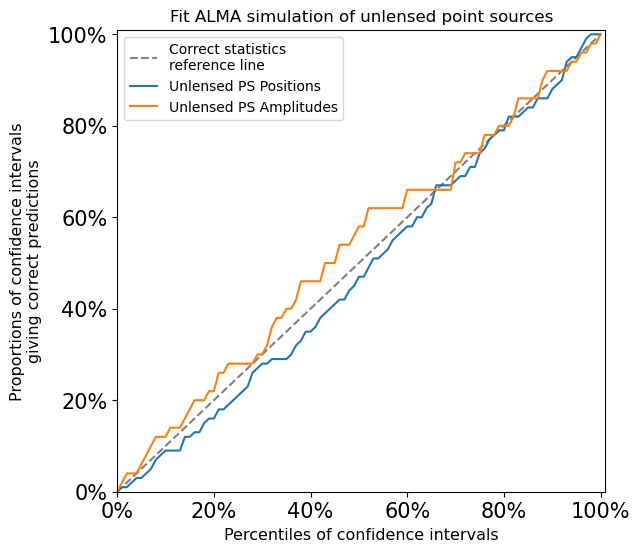

In [36]:
quantile_x = np.linspace(0,1,101)

fig = plt.figure(figsize=(6.3,6))
plt.plot(quantile_x, quantile_x,'--',color='gray',label='Correct statistics\nreference line')
plt.plot(quantile_x, quantile_ra_dec_image_unlensed_ps, label='Unlensed PS Positions')
plt.plot(quantile_x, quantile_amp_unlensed_ps, label='Unlensed PS Amplitudes')
plt.xlim([0, 1.01])
plt.ylim([0, 1.01])
plt.gca().set_yticklabels([f'{x:.0%}' for x in plt.gca().get_yticks()]) 
plt.gca().set_xticklabels([f'{x:.0%}' for x in plt.gca().get_xticks()]) 
plt.tick_params(axis='both', which='major', labelsize=15)

plt.title("Fit ALMA simulation of unlensed point sources")
plt.ylabel("Proportions of confidence intervals\ngiving correct predictions", fontsize = 11.5)
plt.xlabel("Percentiles of confidence intervals", fontsize = 11.5)
plt.legend()

plt.show()